# Bootstrap

### Zhentao Shi


In [15]:
library(magrittr)
library(tibble)
library(plyr)
set.seed(888)

### World View


* Fundamental question: how to quantify uncertainty.
  * data $(X_1,X_2,\ldots,X_n)$
  * sample mean $\bar{X}$
  * sample variance $s$
  * frequentist confidence interval about the population mean

* Asymptotics is imaginary.
* Let's be realistic: we have a finite sample $n$.

## Bootstrap

* Let $X_1, X_2, \ldots, X_n \sim F$ be an i.i.d. sample of $n$ observations following a distribution $F$. 
* The finite sample distribution of a statistic $T_n(\theta)\sim G_n(\cdot, F)$ usually depends on the sample size $n$, as well as the unknown true distribution $F$. 


### Key Idea

* Bootstrap replaces the unknown distribution $F$ in $G_n(\cdot, F)$ by the empirical distribution function

$$
\hat{F}_n(\cdot) = n^{-1} \sum_{i=1}^n 1\{\cdot \leq X_i\}
$$

* Bootstrap inference is drawn from the bootstrap distribution

$$
G_n(\cdot, \hat{F}_n)
$$



### Compare to Asymptotic Theory

* Bootstrap is a finite-sample practice 
* It doesn't refer to an imaginary world where $n\to \infty$ at its face value


* Asymptotic theory approximates $G_n(\cdot, F)$ by its limit 

$$
G(\cdot, F) := \lim_{n\to\infty} G_n(\cdot, F).
$$ 

* In many cases $G(\cdot, F)$ is independent of $F$ and it becomes $G(\cdot)$. Such a $T_n(\theta)$ is called *asymptotically pivotal*, 

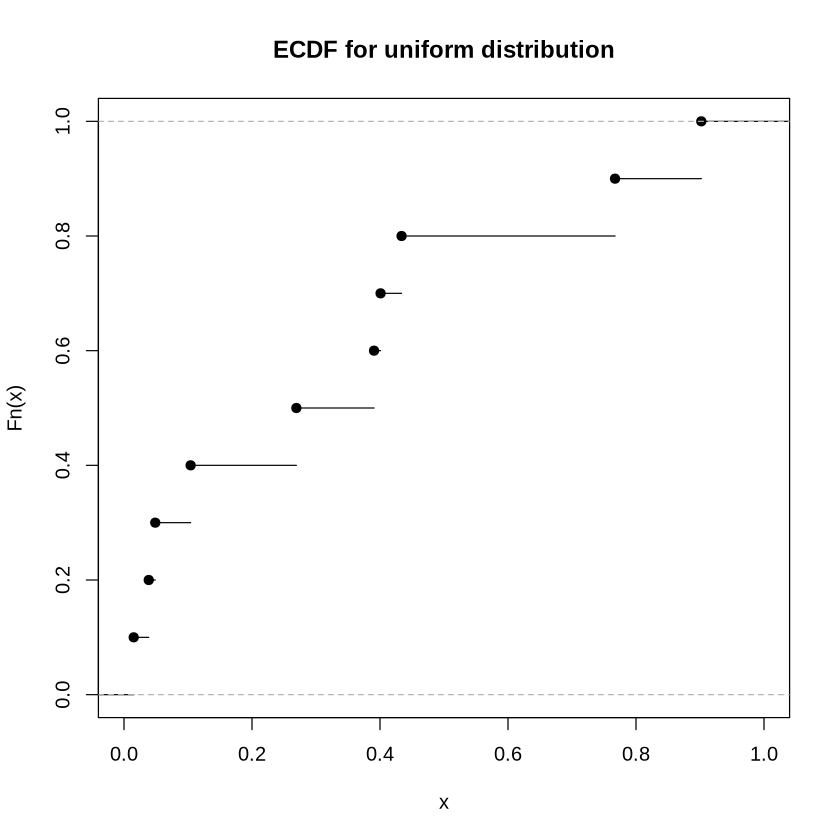

In [16]:
require(tidyverse)

runif(10) %>%
  ecdf() %>%
  plot(, xlim = c(0, 1), main = "ECDF for uniform distribution")


### Nonparametric Bootstrap

* Implementation of bootstrap is a simulation exercise. 
* In an i.i.d. environment, $n$ observations are drawn with equal weight and **with replacement** from the realized sample

### Variants of Bootstrap Schemes

* Block bootstrap: preserve dependence structure
  * dependent dataset such as time series
  * clustering data or networks

* parametric bootstrap
  * In regressions we fix the regressors

In [17]:
n <- 9 # real sample size
real_sample <- rnorm(n) # the real sample
d0 <- tibble(no = 1:n, x = real_sample)
print(d0)

###### bootstrap 
boot_Rep <- 3 # bootstrap 3 times
d_boot <- list() # save the bootstrap sample
for (b in 1:boot_Rep) {
  boot_index <- sample(1:n, n, replace = TRUE)
  d_boot[[b]] <- tibble(no = boot_index, x = real_sample[boot_index])
}

d_boot %>% as_tibble(, .name_repair = "minimal") %>% print()

# A tibble: 9 × 2
     no      x
  <int>  <dbl>
1     1  1.10 
2     2  0.317
3     3  1.36 
4     4  0.956
5     5  0.406
6     6 -0.501
7     7 -1.14 
8     8  1.18 
9     9 -0.191
# A tibble: 9 × 3
  ``$no     $x ``$no     $x ``$no     $x
  <int>  <dbl> <int>  <dbl> <int>  <dbl>
1     5  0.406     1  1.10      9 -0.191
2     6 -0.501     2  0.317     5  0.406
3     5  0.406     9 -0.191     1  1.10 
4     4  0.956     9 -0.191     4  0.956
5     4  0.956     6 -0.501     9 -0.191
6     5  0.406     8  1.18      8  1.18 
7     5  0.406     1  1.10      9 -0.191
8     4  0.956     8  1.18      2  0.317
9     6 -0.501     2  0.317     8  1.18 


### Bootstrap Estimation


* R package [boot](http://cran.r-project.org/web/packages/boot/index.html) provides a general function `boot()`.
* `ply`-family functions for repeated simulations. 

* Bootstrap is convenient. 
  * Analytic formula of the variance of an econometric estimator can be complex to derive or code up.

### Bootstrap Test

* Bootstrap is particularly helpful in inference

### Example

* Test a hypothesis about the population mean. 

* Use $t$-statistic
* Distribution of the sample is either
  * normal
  * zero-centered chi-square 

* We will show that the bootstrap test size is
more precise than that of the asymptotic approximation.


In [18]:
# the t-statistic for a null hypothesis mu
T_stat <- function(Y, mu) sqrt(n) * (mean(Y) - mu) / sd(Y)

# the bootstrap function
boot_test <- function(Y, boot_Rep) {
  # INPUT; Y: the sample;  boot_Rep: number of bootstrap replications

  n <- length(Y)
  boot_T <- rep(0, boot_Rep)

  for (r in 1:boot_Rep) {   # bootstrap in action
    indices <- sample.int(n, n, replace = T) # resampling the index
    resampled_Y <- Y[indices] # construct a bootstrap artificial sample
    boot_T[r] <- abs(T_stat(resampled_Y, mean(Y)))
    # the bootstrapped t-statistic
    # mu is replaced by "mean(Y)" to mimic the situation under the null
  }

  boot_critical_value <- quantile(boot_T, 1 - alpha)   # bootstrap critical value
  return(boot_critical_value)   # bootstrap test decision
}


### Bootstrap World

* The null hypothesis must be imposed no matter the hypothesized parameter is true value or not.

* Bootstrap $t$-statistic is

$$
T^{*}_{n} = \frac{\sqrt{n} (\bar{X^{*}} - \bar{X}) } { s^{*}  }.
$$



### Design the Statistic


* In the bootstrap world the **true** distribution is $F_n$
* The bootstrap $t$-statistic is centered around $\bar{X}$, the sample mean of $F_n$
* If we wrongly center it around the population mean $\theta$, then the test will have no power when the null hypothesis is false.

The following chuck of code report the rejection probability from three decision rules.

In [19]:
compare <- function() {
  # this function generates a sample of n observations
  # and it returns the testing results from three decision rules

  if (distribution == "normal") {
    X <- rnorm(n)
  }
  else if (distribution == "chisq") {
    X <- rchisq(n, df = 3) - 3
  }

  t_value_X <- T_stat(X, mu) # T-statistic

  # compare it to the 97.5% of t-distribution
  exact <- abs(t_value_X) > qt(0.975, df = n - 1)
  # compare it to the 97.5% of normal distribution
  asym <- abs(t_value_X) > 1.96
  # decision from bootstrap
  boot_rule <- abs(t_value_X) > boot_test(X, boot_Rep)

  return(c(exact, asym, boot_rule))
}

In [20]:
# set the parameters
n <- 10
distribution <- "normal"
boot_Rep <- 199
MC_rep <- 2000
alpha <- 0.05
mu <- 0

# Monte Carlo simulation and report the rejection probability
res <- plyr::ldply(.data = 1:MC_rep, .fun = function(i) compare())
colnames(res) <- c("exact", "asym", "bootstrap")
print(colMeans(res))

    exact      asym bootstrap 
   0.0450    0.0755    0.0395 


### Results

* The program reports the empirical size.
* Nominal size of the test is 5%. 
* Bootstrap test is more accurate


* When the underlying distribution is a $\chi^2$, the exact distribution is difficult 
to derive analytically. 
* However, we can still compare the asymptotic size with the bootstrap size.


In [21]:
distribution <- "chisq"

res <- plyr::ldply(.data = 1:MC_rep, .fun = function(i) compare())
colnames(res) <- c("exact?", "asym", "bootstrap")
print(colMeans(res))


   exact?      asym bootstrap 
   0.0695    0.0990    0.0500 


* Here the "exact test" is no longer exact. 
* The asymptotic test works fairly reasonable
* Bootstrap is closer to the nominal size 5%.
